In [1]:
!pip install -qqq nibabel scikit-image torch torchvision tqdm matplotlib -qqq

In [2]:
import os
import subprocess
import sys

STORAGE_DIR = "/content/data"

SYNTHRAD_FILES = [
    {
        "name": "Task1.zip",
        "url": "https://zenodo.org/records/7260705/files/Task1.zip?download=1",
    },
]

VAL_FILES = [
    {
        "name": "Task1_val.zip",
        "url": "https://zenodo.org/records/7868169/files/Task1_val.zip?download=1",
    },
]


def download_and_extract(file_info, save_dir):
    import zipfile

    name = file_info["name"]
    url = file_info["url"]
    zip_path = os.path.join(save_dir, name)
    extract_dir = os.path.join(save_dir, name.replace(".zip", "").replace(".rar", ""))

    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(extract_dir, exist_ok=True)

    if not os.path.exists(zip_path) or os.path.getsize(zip_path) < 1024:
        print(f"Downloading {name} ...")
        subprocess.run(
            ["curl", "-L", "-C", "-", "--progress-bar", "-o", zip_path, url], check=True
        )
        print(f"Downloaded: {name}")
    else:
        print(f"Already exists: {name} ({os.path.getsize(zip_path)/1e9:.2f} GB)")

    ext = os.path.splitext(name)[1].lower()
    print(f"Extracting {name} -> {extract_dir} ...")

    if ext == ".zip":
        with zipfile.ZipFile(zip_path, "r") as zf:
            members = zf.namelist()
            for i, member in enumerate(members):
                zf.extract(member, extract_dir)
                if i % 50 == 0:
                    print(f"  {i}/{len(members)} files extracted...", end="\r")
        print(f"\nExtracted: {name}")
    else:
        print(f"Unknown extension {ext}, skipping extraction.")
        return


def check_disk_space(path, required_gb=200):
    stat = os.statvfs(path)
    avail = stat.f_bavail * stat.f_frsize / 1e9
    print(f"Available space at {path}: {avail:.1f} GB")
    if avail < required_gb:
        print(f"WARNING: less than {required_gb}GB free. Proceed carefully.")
    return avail


if __name__ == "__main__":
    print("=== SynthRAD2023 Dataset Download ===")
    check_disk_space("/content", required_gb=200)

    all_files = SYNTHRAD_FILES
    for file_info in all_files:
        try:
            download_and_extract(file_info, STORAGE_DIR)
        except subprocess.CalledProcessError as e:
            print(f"ERROR on {file_info['name']}: {e}")
            sys.exit(1)

    print("=== All downloads and extractions complete ===")
    print(f"Data location: {STORAGE_DIR}")

=== SynthRAD2023 Dataset Download ===
Available space at /content: 93.6 GB
Downloaded: Task1.zip
Extracting Task1.zip -> /content/data/Task1 ...

Extracted: Task1.zip
=== All downloads and extractions complete ===
Data location: /content/data


Model + preprocessing loaded.
Device: cpu
Stats: {'ct_clip_min': -1000.0, 'ct_clip_max': 1000.0, 'ct_global_mean': -626.06, 'ct_global_std': 551.81, 'mr_p01_mean': 0.49, 'mr_p99_mean': 989.77, 'mr_p01_std': 0.99, 'mr_p99_std': 577.06}
Model loaded. Params: 31,024,705  |  Epoch: 1
Volume shape: (232, 271, 206)
Inference done.
MAE  : 549.75 HU
SSIM : 0.6235
PSNR : 12.17 dB


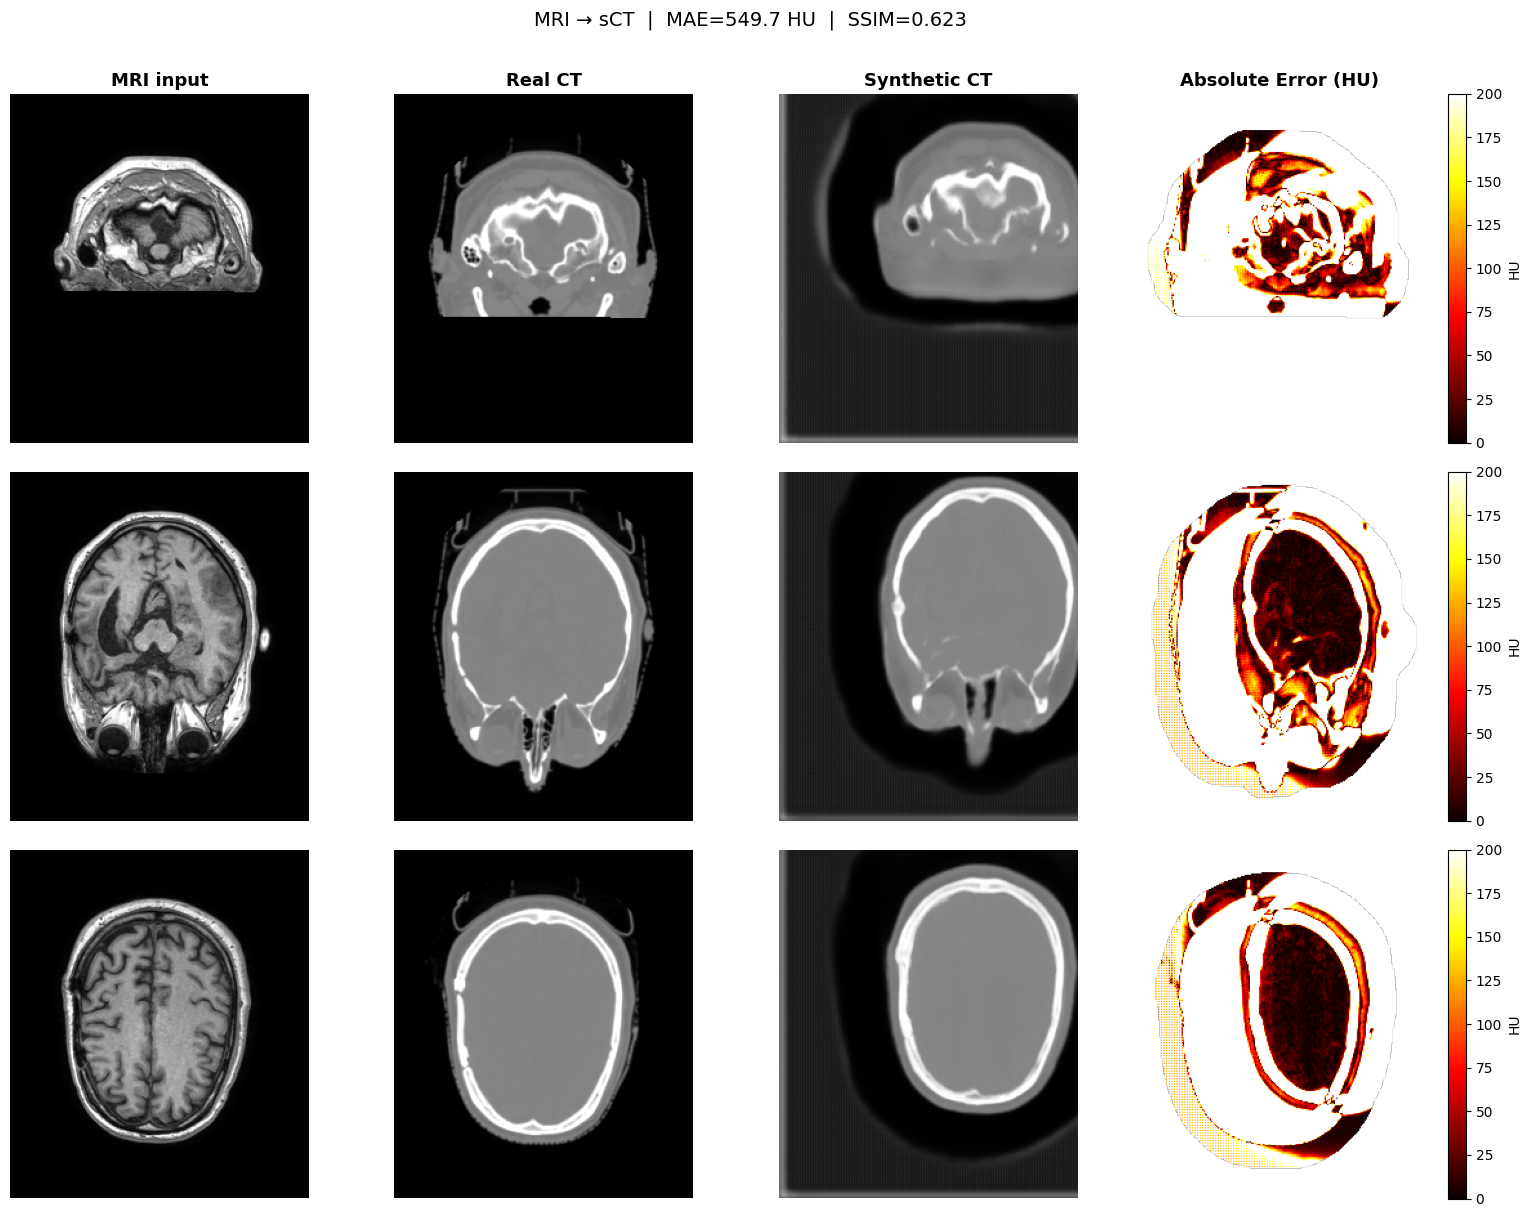

Saved: /content/sct_comparison.png


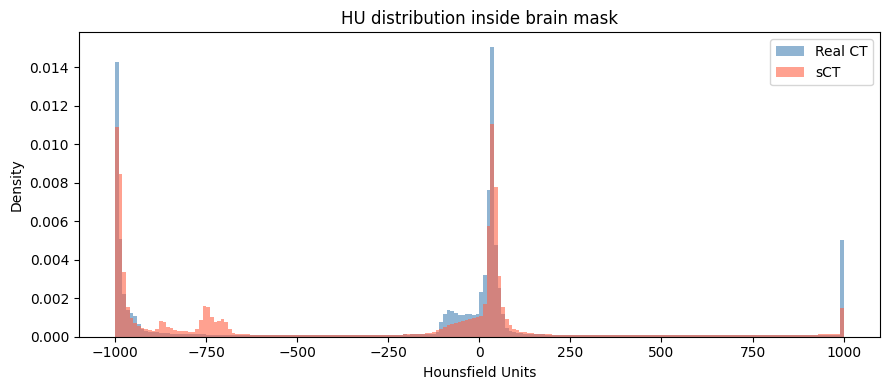

Saved: /content/hu_histogram.png


IndexError: list index out of range

In [3]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import json
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

class ConvBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=64):
        super().__init__()
        b = base_ch
        self.enc1     = ConvBlock2D(in_ch, b)
        self.enc2     = ConvBlock2D(b,     b*2)
        self.enc3     = ConvBlock2D(b*2,   b*4)
        self.enc4     = ConvBlock2D(b*4,   b*8)
        self.bottleneck = ConvBlock2D(b*8, b*16)
        self.up4      = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4     = ConvBlock2D(b*16, b*8)
        self.up3      = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3     = ConvBlock2D(b*8,  b*4)
        self.up2      = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2     = ConvBlock2D(b*4,  b*2)
        self.up1      = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1     = ConvBlock2D(b*2,  b)
        self.pool     = nn.MaxPool2d(2)
        self.head     = nn.Conv2d(b, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)

def pad_to_target(arr, target_h, target_w):
    h, w       = arr.shape
    pad_top    = (target_h - h) // 2
    pad_bottom = target_h - h - pad_top
    pad_left   = (target_w - w) // 2
    pad_right  = target_w - w - pad_left
    return np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right)),
                  mode="constant", constant_values=0)

def preprocess_mr(vol, mask=None):
    brain_voxels = vol[mask > 0] if mask is not None else vol[vol > 0]
    if brain_voxels.size == 0:
        brain_voxels = vol
    p01 = float(np.percentile(brain_voxels, 1))
    p99 = float(np.percentile(brain_voxels, 99))
    vol = np.clip(vol, p01, p99)
    vol = (vol - p01) / (p99 - p01 + 1e-8)
    return vol.astype(np.float32)

def postprocess_ct(vol, stats):
    vol = vol * stats["ct_global_std"] + stats["ct_global_mean"]
    vol = np.clip(vol, stats["ct_clip_min"], stats["ct_clip_max"])
    return vol.astype(np.float32)

print("Model + preprocessing loaded.")

# =============================================================================
# CELL 3 — Configuration: set your file paths here
# =============================================================================
CKPT_PATH  = "/content/best_model.pt"          # upload your checkpoint here
MR_PATH    = "/content/data/Task1/Task1/brain/1BA005/mr.nii.gz"
CT_PATH    = "/content/data/Task1/Task1/brain/1BA005/ct.nii.gz"
MASK_PATH  = "/content/data/Task1/Task1/brain/1BA005/mask.nii.gz"
STATS_PATH = "/content/normalization_stats.json"

# Model config — must match the checkpoint you're using
BASE_CH     = 64    # base_ch from config
TARGET_SIZE = 320   # target_size from config
SPATIAL_MODE = "2D" # "2D" or "2.5D"
N_ADJACENT   = 3    # only used if SPATIAL_MODE == "2.5D"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# =============================================================================
# CELL 4 — Load model and data
# =============================================================================
with open(STATS_PATH) as f:
    stats = json.load(f)
print("Stats:", {k: round(v, 2) for k, v in stats.items() if isinstance(v, float)})

in_ch = N_ADJACENT if SPATIAL_MODE == "2.5D" else 1
model = UNet2D(in_ch=in_ch, out_ch=1, base_ch=BASE_CH)
ckpt  = torch.load(CKPT_PATH, map_location="cpu")
state = ckpt.get("model_state", ckpt)
# Strip DataParallel "module." prefix if present
state = {k.replace("module.", ""): v for k, v in state.items()}
model.load_state_dict(state)
model.eval().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Params: {n_params:,}  |  Epoch: {ckpt.get('epoch', '?')}")

mr_vol   = nib.load(MR_PATH).get_fdata(dtype=np.float32)
ct_vol   = nib.load(CT_PATH).get_fdata(dtype=np.float32)
mask_vol = nib.load(MASK_PATH).get_fdata(dtype=np.float32)
print(f"Volume shape: {mr_vol.shape}")

# =============================================================================
# CELL 5 — Run inference (2D slice-by-slice)
# =============================================================================
mr_proc = preprocess_mr(mr_vol, mask=mask_vol)
sct_norm = np.zeros_like(mr_proc)

with torch.no_grad():
    for z in range(mr_proc.shape[2]):
        if SPATIAL_MODE == "2D":
            sl   = mr_proc[:, :, z]
            h, w = sl.shape
            sl_p = pad_to_target(sl, TARGET_SIZE, TARGET_SIZE)
            inp  = torch.from_numpy(sl_p).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
        else:  # 2.5D
            half   = N_ADJACENT // 2
            n_z    = mr_proc.shape[2]
            slices = []
            for offset in range(-half, half + 1):
                zi = int(np.clip(z + offset, 0, n_z - 1))
                sl = mr_proc[:, :, zi]
                h, w = sl.shape
                slices.append(pad_to_target(sl, TARGET_SIZE, TARGET_SIZE))
            inp = torch.from_numpy(np.stack(slices, 0)).unsqueeze(0).float().to(DEVICE)

        out = model(inp).squeeze().cpu().numpy()
        sct_norm[:, :, z] = out[:h, :w]

sct_hu = postprocess_ct(sct_norm, stats)
ct_hu  = np.clip(ct_vol, stats["ct_clip_min"], stats["ct_clip_max"])
print("Inference done.")

# =============================================================================
# CELL 6 — Per-slice metrics
# =============================================================================
mae_list, ssim_list, psnr_list = [], [], []
for z in range(mr_proc.shape[2]):
    m = mask_vol[:, :, z] > 0
    if m.sum() < 100:
        continue
    pred_sl = sct_hu[:, :, z]
    ct_sl   = ct_hu[:, :, z]
    mae     = np.abs(pred_sl[m] - ct_sl[m]).mean()
    dr      = ct_sl[m].max() - ct_sl[m].min()
    p_s = pred_sl.copy(); p_s[~m] = 0
    c_s = ct_sl.copy();   c_s[~m] = 0
    mae_list.append(mae)
    ssim_list.append(ssim_fn(c_s, p_s, data_range=float(dr)))
    psnr_list.append(psnr_fn(c_s, p_s, data_range=float(dr)))

print(f"MAE  : {np.mean(mae_list):.2f} HU")
print(f"SSIM : {np.mean(ssim_list):.4f}")
print(f"PSNR : {np.mean(psnr_list):.2f} dB")

# =============================================================================
# CELL 7 — Visualize: axial slices at 3 levels (top / mid / bottom of brain)
# =============================================================================
mask_slices = [z for z in range(mr_proc.shape[2]) if mask_vol[:, :, z].mean() > 0.05]
n_z    = len(mask_slices)
z_show = [mask_slices[n_z // 4], mask_slices[n_z // 2], mask_slices[3 * n_z // 4]]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
col_titles = ["MRI input", "Real CT", "Synthetic CT", "Absolute Error (HU)"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold")

for row, z in enumerate(z_show):
    mr_sl   = mr_proc[:, :, z].T
    ct_sl   = ct_hu[:, :, z].T
    sct_sl  = sct_hu[:, :, z].T
    err_sl  = np.abs(sct_hu[:, :, z] - ct_hu[:, :, z]).T
    m_sl    = mask_vol[:, :, z].T > 0

    axes[row, 0].imshow(mr_sl,  cmap="gray", origin="lower")
    axes[row, 1].imshow(ct_sl,  cmap="gray", vmin=-1000, vmax=1000, origin="lower")
    axes[row, 2].imshow(sct_sl, cmap="gray", vmin=-1000, vmax=1000, origin="lower")
    im = axes[row, 3].imshow(np.where(m_sl, err_sl, np.nan),
                              cmap="hot", vmin=0, vmax=200, origin="lower")
    axes[row, 0].set_ylabel(f"z={z}", fontsize=10)
    plt.colorbar(im, ax=axes[row, 3], label="HU")

for ax in axes.ravel():
    ax.axis("off")

plt.suptitle(f"MRI → sCT  |  MAE={np.mean(mae_list):.1f} HU  |  SSIM={np.mean(ssim_list):.3f}",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/content/sct_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/sct_comparison.png")

# =============================================================================
# CELL 8 — HU histogram: Real CT vs sCT (within mask)
# =============================================================================
mask_3d = mask_vol > 0
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ct_hu[mask_3d].ravel(),  bins=200, alpha=0.6, label="Real CT",  color="steelblue", density=True)
ax.hist(sct_hu[mask_3d].ravel(), bins=200, alpha=0.6, label="sCT",      color="tomato",    density=True)
ax.set_xlabel("Hounsfield Units"); ax.set_ylabel("Density")
ax.set_title("HU distribution inside brain mask"); ax.legend()
plt.tight_layout()
plt.savefig("/content/hu_histogram.png", dpi=150)
plt.show()
print("Saved: /content/hu_histogram.png")

# =============================================================================
# CELL 9 — Per-slice MAE along z-axis
# =============================================================================
z_indices = [mask_slices[i] for i in range(len(mae_list))]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(z_indices, mae_list, linewidth=1.5, color="steelblue")
ax.axhline(np.mean(mae_list), color="tomato", linestyle="--", label=f"Mean = {np.mean(mae_list):.1f} HU")
ax.set_xlabel("Axial slice index"); ax.set_ylabel("MAE (HU)")
ax.set_title("Per-slice MAE"); ax.legend()
plt.tight_layout()
plt.savefig("/content/per_slice_mae.png", dpi=150)
plt.show()